# Combined Cycle Power Plant Output Prediction using ANN (Regression)

This notebook builds an Artificial Neural Network using **TensorFlow / Keras** to predict the **net hourly electrical energy output (PE)** of a combined cycle power plant.

**Dataset**: UCI Combined Cycle Power Plant (CCPP) - 9,568 hourly observations, downloaded programmatically from the UCI ML repository.

**Features**:
- `AT` - Ambient Temperature (degC)
- `V`  - Exhaust Vacuum (cm Hg)
- `AP` - Ambient Pressure (mbar)
- `RH` - Relative Humidity (%)

**Target**:
- `PE` - Net hourly electrical energy output (MW)

Pipeline:
- `Dense` layers
- `BatchNormalization` (to stabilise / speed up training)
- `Dropout` (to reduce overfitting)
- `EarlyStopping` callback

## 1. Import Libraries

In [2]:
import io
import ssl
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1787199381.776164   15855 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787199381.776786   15855 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787199381.823322   15855 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787199383.122618   15855 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 2. Download & Load the Dataset

The dataset is downloaded **programmatically** from the UCI ML repository and read directly from the Excel file inside the ZIP - no manual download required.

In [3]:
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip"

# # SSL workaround for environments with strict certificate checks
# ctx = ssl.create_default_context()
# ctx.check_hostname = False
# ctx.verify_mode = ssl.CERT_NONE

# req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
# with urllib.request.urlopen(req, context=ctx, timeout=60) as resp:
#     zip_bytes = resp.read()

# print(f"Downloaded {len(zip_bytes):,} bytes")

# with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
#     with z.open("CCPP/Folds5x2_pp.xlsx") as f:
#         df = pd.read_excel(f)

# df.head()

In [11]:
df = pd.read_csv("Life Expectancy Data.csv")
pd.set_option('display.max_columns', None)
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [12]:
df.shape

(2938, 22)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [14]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


## 3. Data Cleaning

In [15]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("After dropping duplicates:", df.shape)

Duplicate rows: 0
After dropping duplicates: (2938, 22)


In [16]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [9]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [17]:
df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})
df['Status'].value_counts()

Status
0    2426
1     512
Name: count, dtype: int64

In [18]:
miss = df.isnull().sum()
miss_pct = (miss / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': miss, 'Percentage': miss_pct})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)
missing_data

,Missing Values,Percentage
Population,652,22.191967
Hepatitis B,553,18.822328
GDP,448,15.248468
Total expenditure,226,7.692308
Alcohol,194,6.603131
Income composition of resources,167,5.684139
Schooling,163,5.547992
thinness 5-9 years,34,1.157250
thinness 1-19 years,34,1.157250
BMI,34,1.157250


## 4. Exploratory Data Analysis

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'Afghanistan'

<Figure size 800x600 with 0 Axes>

In [10]:
target = "PE"     
X = df.drop(columns=[target])

corr_matrix = X.corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.8:
            col1 = corr_matrix.columns[j]
            col2 = corr_matrix.columns[i]
            corr = corr_matrix.iloc[i, j]

            print(f"{col1} ↔ {col2} = {corr:.3f}")

            columns_to_drop.append(col2)

print("\nColumns to drop:", columns_to_drop)

AT ↔ V = 0.844

Columns to drop: ['V']


In [11]:
df.drop(columns=columns_to_drop, inplace=True)

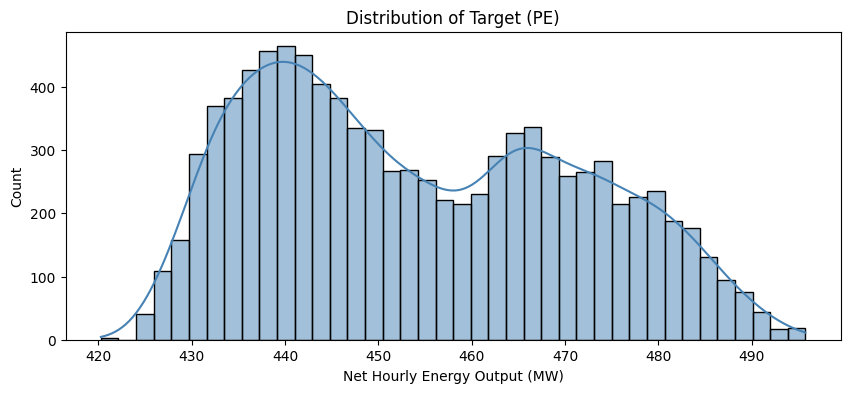

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df['PE'], kde=True, bins=40, color='steelblue')
plt.title('Distribution of Target (PE)')
plt.xlabel('Net Hourly Energy Output (MW)')
plt.show()

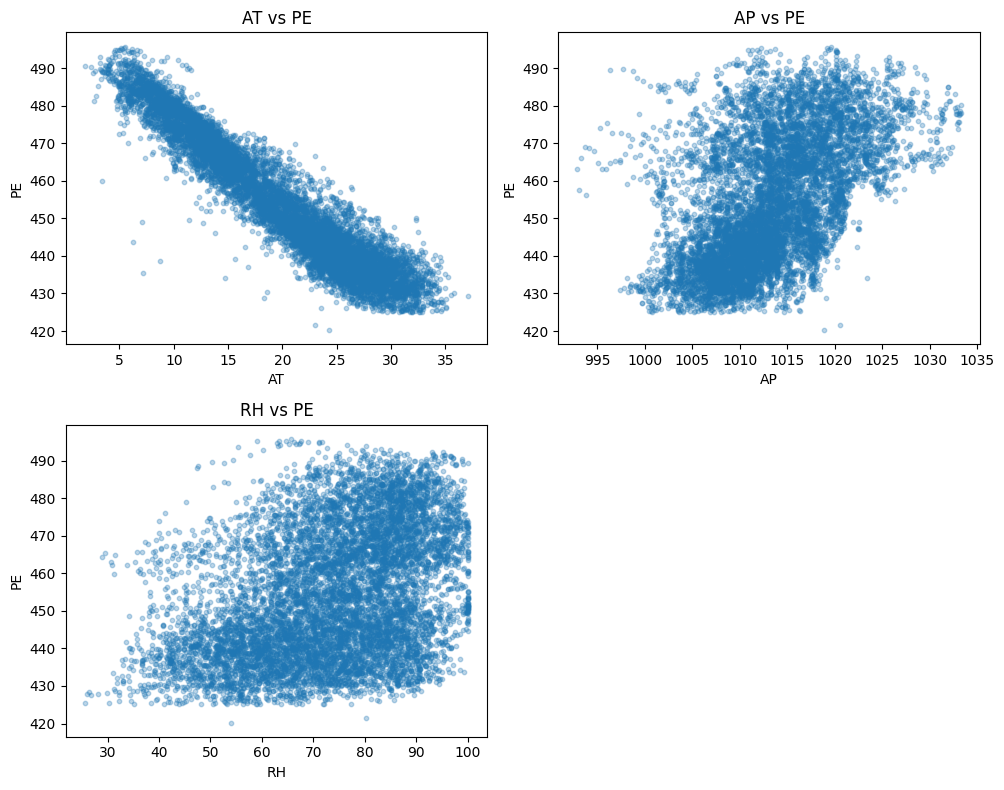

In [11]:
import matplotlib.pyplot as plt

cols = ['AT', 'AP', 'RH']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.scatter(df[col], df['PE'], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel('PE')
    ax.set_title(f'{col} vs PE')

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [12]:
X = df.drop(columns=['PE'])
y = df['PE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (6668, 3)  X_test: (2859, 3)
y_train: (6668,)  y_test: (2859,)


## 6. Feature Scaling

Only the **features (X)** are scaled with `MinMaxScaler`. The target `PE` is kept in its original scale (MW) so all metrics are directly interpretable.

In [13]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
print("n_features:", n_features)

n_features: 3


## 7. Build the ANN

In [ ]:
model = Sequential()

# Input layer
model.add(Input(shape=(n_features,))) # To pass as a tuple, without comma(,), it would be an integer

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

# Output layer
model.add(Dense(1, activation='linear'))

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 192 (768.00 B)

## 8. Train the Model

`EarlyStopping` halts training once the validation loss stops improving and restores the best weights.

In [16]:
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.01,
    patience=25,
    verbose=1,
    mode="min",
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 205848.0938 - mae: 453.5022 - val_loss: 203705.0469 - val_mae: 451.0590
Epoch 2/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 201991.7344 - mae: 449.3584 - val_loss: 196792.3906 - val_mae: 443.4637
Epoch 3/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 194316.5938 - mae: 440.7491 - val_loss: 189089.2188 - val_mae: 434.7912
Epoch 4/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 183060.5938 - mae: 427.7694 - val_loss: 173542.0625 - val_mae: 416.5485
Epoch 5/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 168749.5156 - mae: 410.6912 - val_loss: 160970.5938 - val_mae: 401.1799
Epoch 6/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 152491.9531 - mae: 390.3608 - val_loss: 143080.3438 - val_mae: 378.2258
Epoch 7/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 134748.8750 - mae: 366.8904 - val_loss: 125041.5469 - val_mae: 353.5616
Epoch 8/200
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 116590.1

## 9. Training History

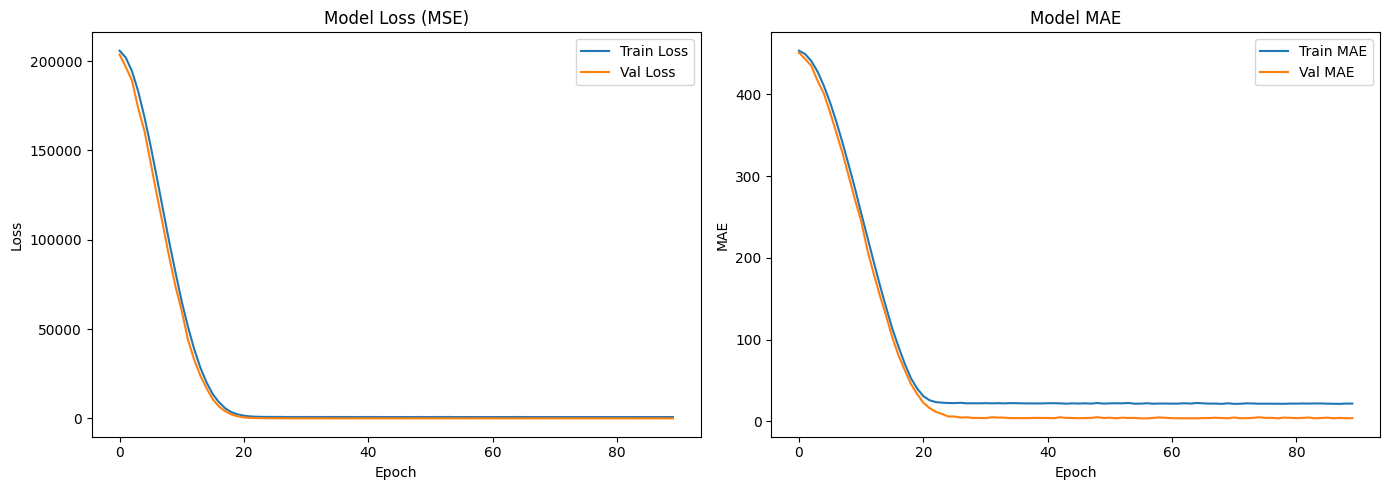

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Evaluate on Test Set

In [18]:
y_pred = model.predict(X_test_scaled).flatten()

y_test_arr = y_test.values
for actual, pred in zip(y_test_arr[10:20], y_pred[10:20]):
    print(f"Actual: {actual:>8.2f}   Predicted: {pred:>8.2f}")

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Actual:   440.87   Predicted:   444.88
Actual:   448.51   Predicted:   452.60
Actual:   456.86   Predicted:   458.54
Actual:   449.96   Predicted:   449.31
Actual:   432.10   Predicted:   438.39
Actual:   430.26   Predicted:   438.76
Actual:   450.46   Predicted:   446.18
Actual:   476.83   Predicted:   478.79
Actual:   456.62   Predicted:   453.48
Actual:   471.31   Predicted:   462.68


In [19]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R\u00b2 Score : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")

R² Score : 0.9281
MAE       : 3.6668
RMSE      : 4.5993


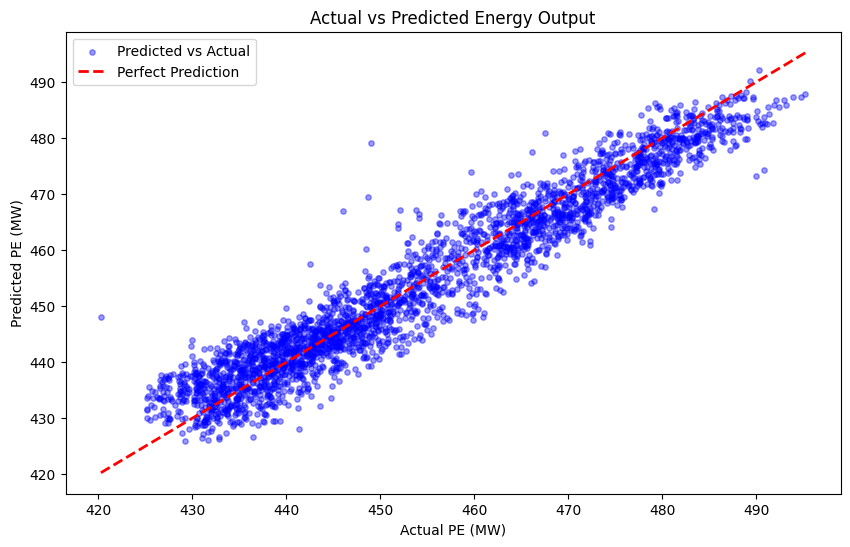

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.4, s=15, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual PE (MW)')
plt.ylabel('Predicted PE (MW)')
plt.title('Actual vs Predicted Energy Output')
plt.legend()
plt.show()

## 11. Inference on New Data

Helper that takes raw sensor values, applies the same scaling pipeline, then predicts using the trained ANN.

In [21]:
def predict_pe(at,ap, rh):
    input_df = pd.DataFrame({
        'AT': [at],
        'AP': [ap],
        'RH': [rh]
    })
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled, verbose=0).flatten()[0]
    return f"Estimated Net Hourly Energy Output: {prediction:,.2f} MW"

# Examples (real rows from the dataset, actual PE shown in comments)
print(predict_pe(at=14.96, ap=1024.07, rh=73.17))  # actual ~ 463.26
print(predict_pe(at=25.18, ap=1020.04, rh=59.08))  # actual ~ 444.37
print(predict_pe(at=5.11, ap=1012.16, rh=92.14))  # actual ~ 488.56

Estimated Net Hourly Energy Output: 463.53 MW
Estimated Net Hourly Energy Output: 445.03 MW
Estimated Net Hourly Energy Output: 484.25 MW


In [ ]:
# model.save('ccpp_ann_model.keras')
# print('Model saved to ccpp_ann_model.keras')